In [7]:
import pandas as pd
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# Read several csv files with the same format, but different names, into one df
biophi = pd.read_csv("../Testing_settings_for_tools/BioPhi(OASis)/ranked_score_table.csv")
IApred = pd.read_csv("../Testing_settings_for_tools/IApred/ranked_score_table.csv")
netMHC_II_pan_BA = pd.read_csv("../Testing_settings_for_tools/NetMHC_II_pan_BA/ranked_score_table.csv")
netMCH_II_pan_EL = pd.read_csv("../Testing_settings_for_tools/NetMHC_II_pan_EL/ranked_score_table.csv")
netMHC_II_pan_immunogen = pd.read_csv("../Testing_settings_for_tools/NetMHC_II_pan_immunogen/ranked_score_table.csv")
netMHC_II_pan_immunogen_combined = pd.read_csv("../Testing_settings_for_tools/NetMHC_II_pan_Immunogen_combined/ranked_score_table.csv")
netMHCpan_BA = pd.read_csv("../Testing_settings_for_tools/NetMHCpan_BA/ranked_score_table.csv")
netMHCpan_EL = pd.read_csv("../Testing_settings_for_tools/NetMHCpan_EL/ranked_score_table.csv")
netMHCpan_immunogen = pd.read_csv("../Testing_settings_for_tools/NetMHCpanImmunogen/ranked_score_table.csv")

In [9]:
# Create new df with all dfs loaded above stacked on each other (they have the same colums so just add them as rows)
all_toolANDsettings = pd.concat([biophi, IApred, 
                                 netMHC_II_pan_BA, netMCH_II_pan_EL, netMHC_II_pan_immunogen, netMHC_II_pan_immunogen_combined, 
                                 netMHCpan_BA, netMHCpan_EL, netMHCpan_immunogen], 
                                 ignore_index=True)

# Sort based on spearmanr
all_toolANDsettings = all_toolANDsettings.sort_values(by='spearmanr', ascending=False)
all_toolANDsettings

,dataframe,sum_MARE,spearmanr,spearmanr_pval,Caplacizumab_MARE,Vobarilizumab_MARE
32,netMHC_II_pan_EL_peplength12_27allels_wind5_AB,360.0,0.401304,0.013827,11.0,-22.5
34,netMHC_II_pan_EL_peplength15_27allels_wind2_AB,361.0,0.383854,0.019007,11.0,-33.0
44,netMHC_II_pan_EL_peplength11_27allels_wind2_AB,357.0,0.361923,0.027725,11.0,-24.0
39,netMHC_II_pan_EL_peplength11_27allels_wind10_AB,368.0,0.334303,0.043146,-26.0,-34.0
83,netMHCpan_immunogen_peptide_length_14_AB,358.0,0.329303,0.046567,11.0,-28.0
...,...,...,...,...,...,...
52,netMHC_II_immunogen_pepl15_allel7_wind5_AB,522.0,-0.281413,0.091544,-24.0,-27.0
58,netMHC_II_immunogenComb_pepl15_allel27_wind2_AB,554.0,-0.344239,0.036952,-21.0,-28.0
59,netMHC_II_immunogenComb_pepl15_allel27_wind10_AB,548.0,-0.365339,0.026183,7.0,-11.0
68,netMHCpan_BA_peplength13_AB,558.0,-0.416217,0.010398,6.0,-28.0


In [10]:
# save it as excel file
all_toolANDsettings.to_excel("all_toolANDsettings.xlsx", index=False)

# Visualization

In [11]:
# First I merge the dfs and include the tool name, so I can sort plots based on tool
dfs = {
    'biophi': biophi,
    'IApred': IApred,
    'netMHC_II_pan_BA': netMHC_II_pan_BA,
    'netMCH_II_pan_EL': netMCH_II_pan_EL,
    'netMHC_II_pan_immunogen': netMHC_II_pan_immunogen,
    'netMHC_II_pan_immunogen_combined': netMHC_II_pan_immunogen_combined,
    'netMHCpan_BA': netMHCpan_BA,
    'netMHCpan_EL': netMHCpan_EL,
    'netMHCpan_immunogen': netMHCpan_immunogen
}

viz_df = pd.concat(
    [df.assign(tool=name) for name, df in dfs.items()],
    ignore_index=True
)

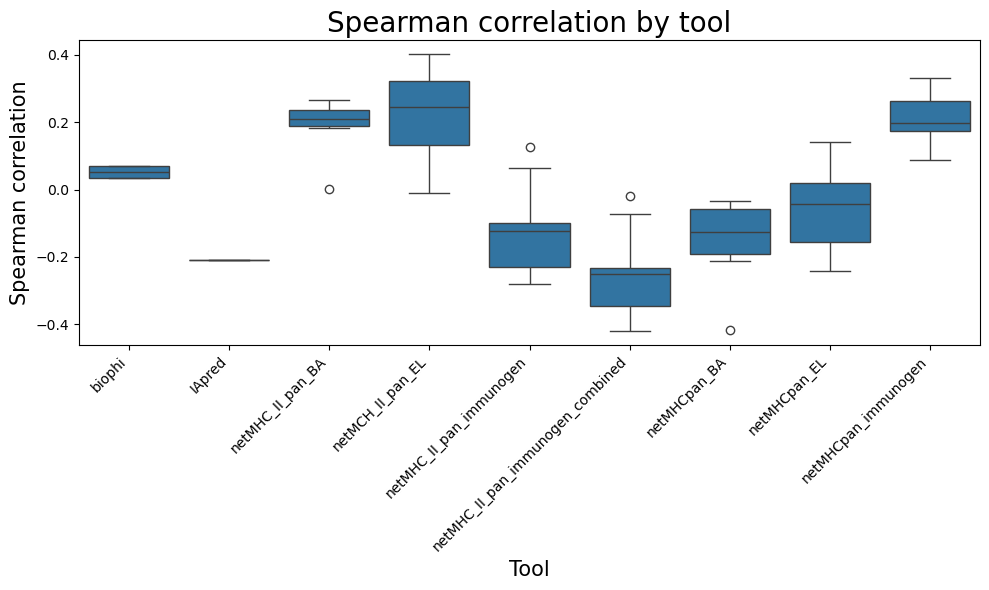

In [12]:
# Boxplot of spearmanr score, grouped by tool
plt.figure(figsize=(10,6))

sns.boxplot(
    data=viz_df,
    x='tool',
    y='spearmanr'
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Tool",fontsize=15)
plt.ylabel("Spearman correlation", fontsize=15)
plt.title("Spearman correlation by tool", fontsize=20)

plt.tight_layout()
plt.show()

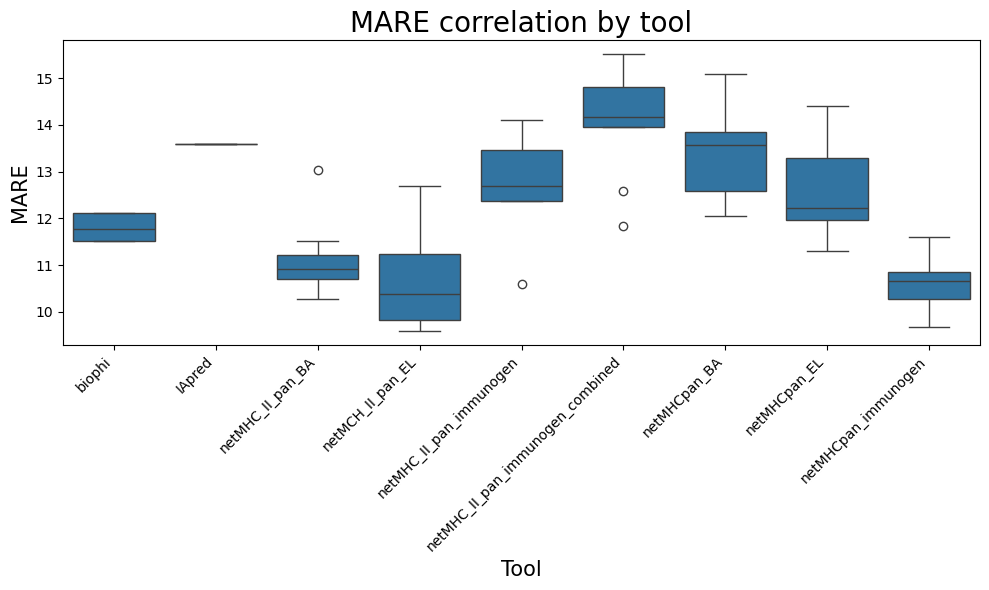

In [16]:
# Boxplot of MARE score, grouped by tool

# Compute the mean value of MARE (as it is supposed to be)
viz_df['MARE'] = viz_df['sum_MARE'].div(37)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=viz_df,
    x='tool',
    y='MARE'
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Tool",fontsize=15)
plt.ylabel("MARE", fontsize=15)
plt.title("MARE correlation by tool", fontsize=20)

plt.tight_layout()
plt.show()

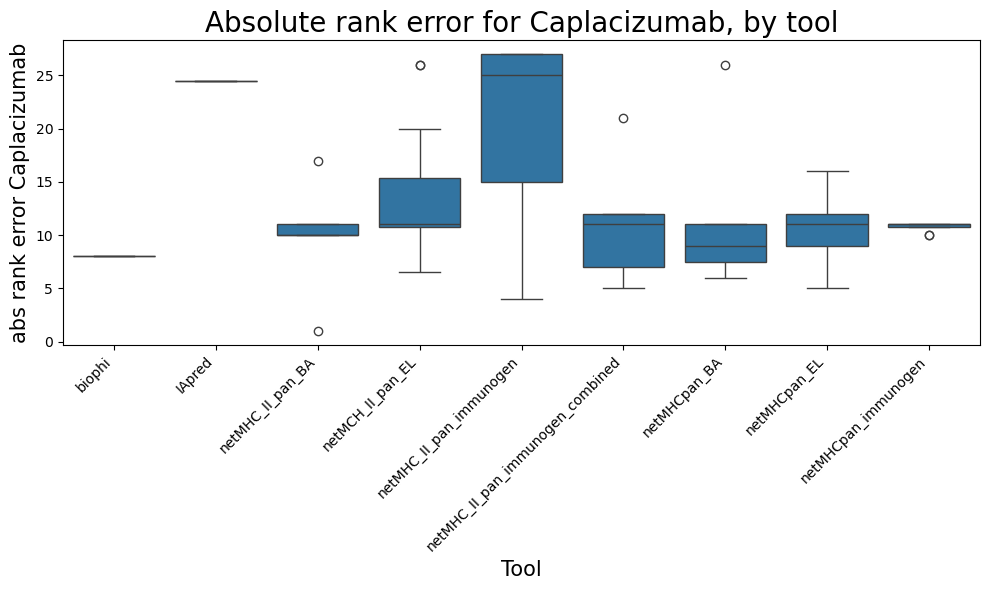

In [17]:
# Boxplot of absolute rank error for Capa, grouped by tool

# Make a new column with the absolute value
viz_df['abs_rank_error_Capa'] = viz_df['Caplacizumab_MARE'].abs()


plt.figure(figsize=(10,6))

sns.boxplot(
    data=viz_df,
    x='tool',
    y='abs_rank_error_Capa'
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Tool",fontsize=15)
plt.ylabel("abs rank error Caplacizumab", fontsize=15)
plt.title("Absolute rank error for Caplacizumab, by tool", fontsize=20)

plt.tight_layout()
plt.show()

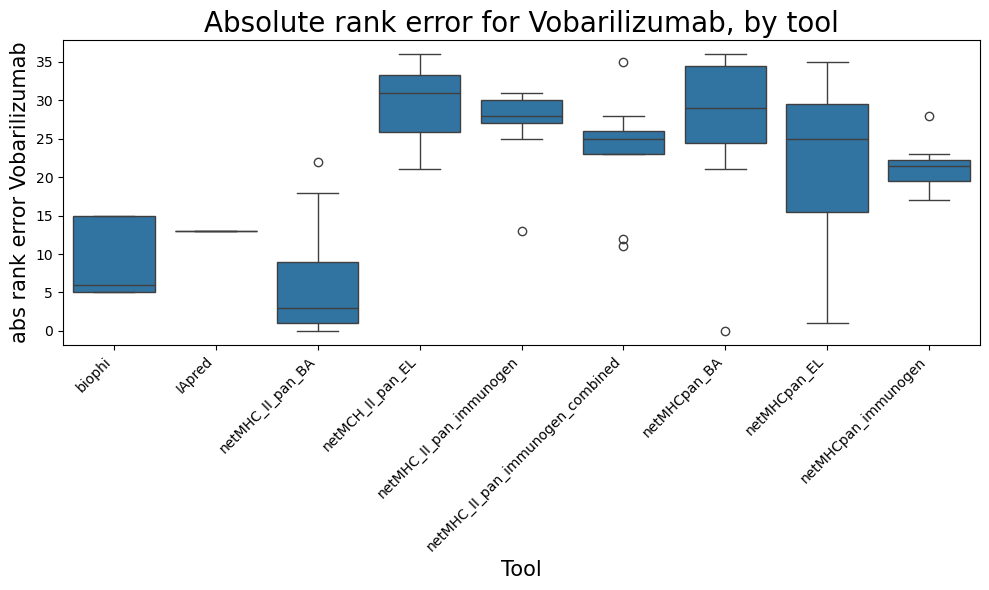

In [18]:
# Boxplot of absolute rank error for Vobarilizumab, grouped by tool

# Make a new column with the absolute value
viz_df['abs_rank_error_Vobar'] = viz_df['Vobarilizumab_MARE'].abs()


plt.figure(figsize=(10,6))

sns.boxplot(
    data=viz_df,
    x='tool',
    y='abs_rank_error_Vobar'
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Tool",fontsize=15)
plt.ylabel("abs rank error Vobarilizumab", fontsize=15)
plt.title("Absolute rank error for Vobarilizumab, by tool", fontsize=20)

plt.tight_layout()
plt.show()